# Image Transformations

A short, self-contained walkthrough of **2D image transformations in homogeneous coordinates**. It builds the three primitive transforms — rotation, translation, and scaling — as 3×3 matrices from scratch, verifies them against known closed-form results, and then demonstrates why **the order of matrix composition matters**: applying the same rotation/translation/scaling in different orders produces visibly different results on both point sets and warped images (using `cv2.warpAffine`).


## 1. Setup

The notebook uses OpenCV, NumPy, Matplotlib, and scikit-image.


In [4]:
!pip -q install opencv-python-headless scikit-image

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.metrics import structural_similarity as ssim

np.random.seed(7)
print("OpenCV version:", cv2.__version__)


OpenCV version: 4.10.0


## 2. Helper functions

These functions show images, points, overlays, and compute simple error scores.


In [6]:
def normalize_uint8(img):
    img = img.astype(np.float32)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return (255 * img).astype(np.uint8)


def show_gray(img, title="Image", figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_points(points, title="Points", xlim=(-150, 250), ylim=(-150, 250)):
    pts = np.asarray(points)
    closed = np.vstack([pts, pts[0]])
    plt.figure(figsize=(5, 5))
    plt.plot(closed[:, 0], closed[:, 1], marker="o")
    for i, (x, y) in enumerate(pts):
        plt.text(x + 3, y + 3, str(i))
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(True)
    plt.title(title)
    plt.show()


def color_overlay(reference, moving):
    ref = normalize_uint8(reference)
    mov = normalize_uint8(moving)
    out = np.zeros((ref.shape[0], ref.shape[1], 3), dtype=np.uint8)
    out[..., 1] = ref      # green channel: reference
    out[..., 0] = mov      # red channel: moving/aligned
    return out


def checker_overlay(a, b, block_size=32):
    a = normalize_uint8(a)
    b = normalize_uint8(b)
    h, w = a.shape
    yy, xx = np.indices((h, w))
    mask = ((xx // block_size + yy // block_size) % 2).astype(bool)
    out = a.copy()
    out[mask] = b[mask]
    return out


def mse(a, b):
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    return float(np.mean((a - b) ** 2))


## 3. Basic 2D transformations

In homogeneous coordinates a 2D point is written as:

$$
\mathbf{x} = [x, y, 1]^T
$$

and a transform is a $3 \times 3$ matrix. The convention used throughout this notebook is **column vectors**:

$$
\mathbf{x}' = M\mathbf{x}
$$

The cell below defines three independent constructors — `rotation_matrix(theta_deg)`, `translation_matrix(tx, ty)`, and `scaling_matrix(sx, sy)` — together with a helper `transform_points` that applies a 3×3 matrix to a batch of `(x, y)` points.


In [7]:
def rotation_matrix(theta_deg):
    """Return a 3x3 homogeneous 2D rotation matrix.

    Args:
        theta_deg: rotation angle in degrees, counter-clockwise.
    """
    theta = np.deg2rad(theta_deg)
    c = np.cos(theta)
    s = np.sin(theta)
    M = np.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)
    return M


def translation_matrix(tx, ty):
    """Return a 3x3 homogeneous 2D translation matrix."""
    M = np.array([
        [1.0, 0.0, tx],
        [0.0, 1.0, ty],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)
    return M


def scaling_matrix(sx, sy):
    """Return a 3x3 homogeneous 2D scaling matrix."""
    M = np.array([
        [sx,  0.0, 0.0],
        [0.0, sy,  0.0],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)
    return M


def transform_points(points_xy, M):
    """Apply a 3x3 homogeneous matrix to Nx2 points."""
    points_xy = np.asarray(points_xy, dtype=np.float64)
    ones = np.ones((points_xy.shape[0], 1), dtype=np.float64)
    points_h = np.hstack([points_xy, ones])
    out_h = (M @ points_h.T).T
    out_xy = out_h[:, :2] / out_h[:, 2:3]
    return out_xy


### 3.1 Unit tests

Quick sanity checks against simple cases where the expected output is known in closed form.


In [8]:
# Test rotation: rotating (1, 0) by 90 degrees should give approximately (0, 1)
p = np.array([[1.0, 0.0]])
out = transform_points(p, rotation_matrix(90))
print("Rotation test:", out)
assert np.allclose(out, [[0.0, 1.0]], atol=1e-7)

# Test translation: translating (1, 2) by (5, -3) should give (6, -1)
p = np.array([[1.0, 2.0]])
out = transform_points(p, translation_matrix(5, -3))
print("Translation test:", out)
assert np.allclose(out, [[6.0, -1.0]])

# Test scaling: scaling (2, 3) by (4, 5) should give (8, 15)
p = np.array([[2.0, 3.0]])
out = transform_points(p, scaling_matrix(4, 5))
print("Scaling test:", out)
assert np.allclose(out, [[8.0, 15.0]])

print("All matrix tests passed.")


Rotation test: [[6.123234e-17 1.000000e+00]]
Translation test: [[ 6. -1.]]
Scaling test: [[ 8. 15.]]
All matrix tests passed.


## 4. Composition order matters

The next cell applies the same three operations in different orders to a square. Because matrix multiplication is not commutative, the final points are usually different.

The three products are:

- `T @ R @ S`: scale first, then rotate, then translate
- `R @ T @ S`: scale first, then translate, then rotate
- `S @ R @ T`: translate first, then rotate, then scale

The operation closest to the point vector happens first.


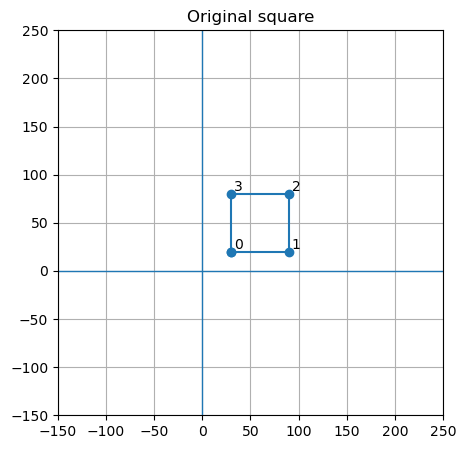

 T @ R @ S
[[108.83  57.28]
 [182.56 108.9 ]
 [158.47 143.31]
 [ 84.74  91.68]]


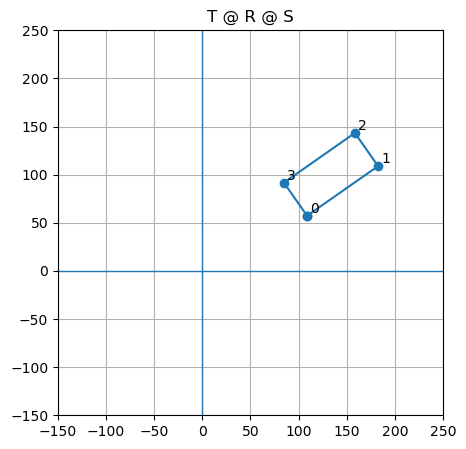

 R @ T @ S
[[ 82.89  99.55]
 [156.62 151.17]
 [132.53 185.57]
 [ 58.8  133.95]]


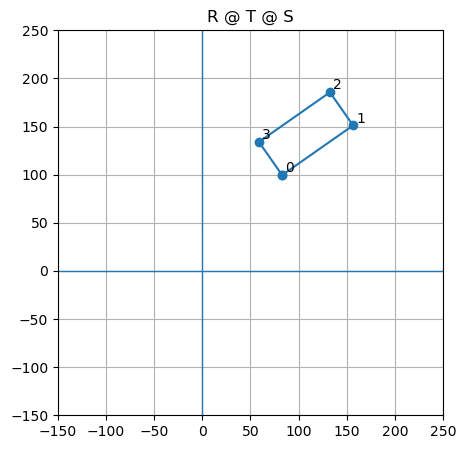

 S @ R @ T
[[100.75  67.1 ]
 [174.47  91.19]
 [122.85 125.6 ]
 [ 49.12 101.51]]


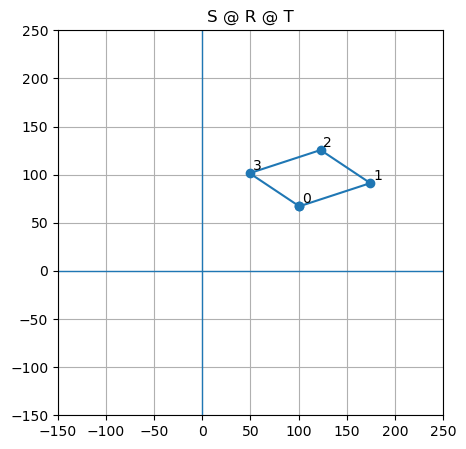

In [9]:
# A simple square centred away from the origin so that rotation effects are easy to see
square_input = np.array([
    [30.0, 20.0],
    [90.0, 20.0],
    [90.0, 80.0],
    [30.0, 80.0]
])

T = translation_matrix(80, 20)
R = rotation_matrix(35)
S = scaling_matrix(1.5, 0.7)

orders = {
    "T @ R @ S": T @ R @ S,
    "R @ T @ S": R @ T @ S,
    "S @ R @ T": S @ R @ T,
}

show_points(square_input, "Original square")
for name, M in orders.items():
    transformed = transform_points(square_input, M)
    print("", name)
    print(np.round(transformed, 2))
    show_points(transformed, name)


**1. Are these transformed objects look the same? Why?**

No — the three squares end up in different positions, orientations, and shapes. Matrix multiplication is not commutative, so `T @ R @ S`, `R @ T @ S` and `S @ R @ T` apply the same primitive operations to the point in a different sequence. In particular, when a rotation is applied *after* a translation it rotates the already-shifted points around the origin (effectively also moving where they end up), and when scaling is applied *after* rotation it stretches along the world axes rather than along the rotated object's axes. Same ingredients, different recipe — different result.

**2. What happens if `sx` and `sy` are different? Which geometric property changes?**

Non-uniform scaling stretches the x- and y-axes by different amounts, so the **aspect ratio** is no longer preserved — a square becomes a non-square rectangle. More generally, the transform stops being a *similarity* and becomes a general *affine* map: lengths along the two axes scale by different factors, and the angle between any two non-axis-aligned edges (e.g. the diagonal of the square) is no longer preserved. Parallel lines stay parallel, but shapes are sheared/squashed along one axis relative to the other.

**3. Try a negative scale value, such as `scaling_matrix(-1, 1)`. What does it do?**

`scaling_matrix(-1, 1)` is a **reflection across the y-axis** (the line `x = 0`): every point `(x, y)` is mapped to `(-x, y)`. The shape is mirrored horizontally — its orientation flips (a clockwise-ordered set of vertices becomes counter-clockwise), so the determinant of the matrix becomes `-1`. Similarly, `scaling_matrix(1, -1)` reflects across the x-axis, and `scaling_matrix(-1, -1)` is a 180° rotation about the origin.


## 5. Apply composed matrices to images

OpenCV image warping uses matrices to map pixel coordinates. Here we use `cv2.warpAffine`, which expects a `2 x 3` affine matrix. We build a `3 x 3` matrix first, then pass its first two rows.


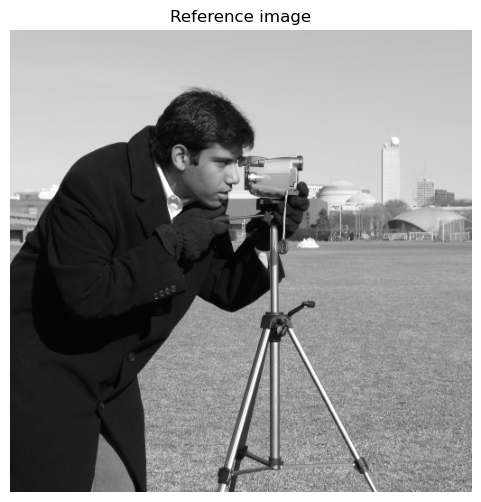

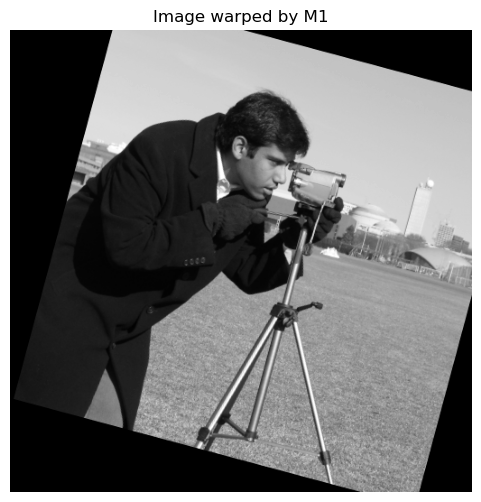

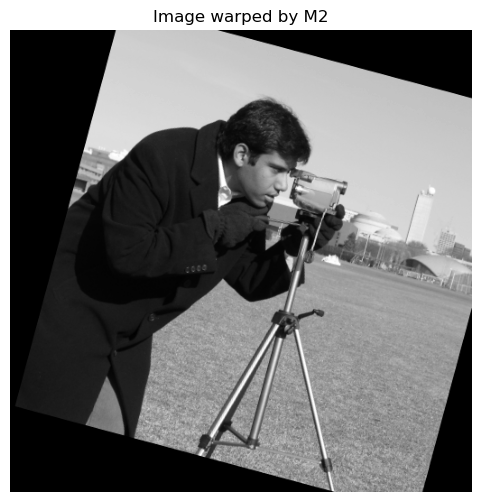

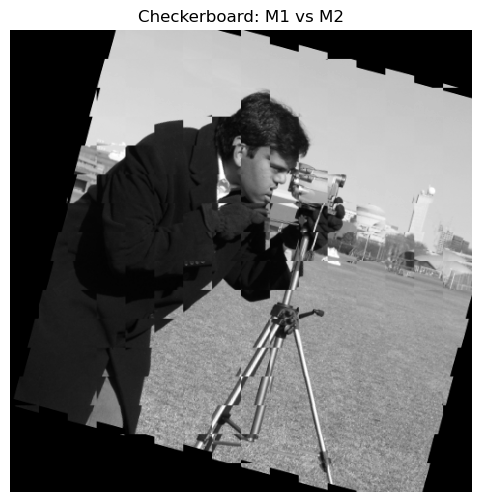

In [10]:
reference = normalize_uint8(data.camera())
h, w = reference.shape
show_gray(reference, "Reference image")

# Move the image centre close to the origin, apply transform, then move it back.
C_to_origin = translation_matrix(-w / 2, -h / 2)
C_back = translation_matrix(w / 2, h / 2)

M1 = C_back @ translation_matrix(30, -10) @ rotation_matrix(15) @ scaling_matrix(0.9, 0.9) @ C_to_origin
M2 = C_back @ rotation_matrix(15) @ translation_matrix(30, -10) @ scaling_matrix(0.9, 0.9) @ C_to_origin

warped_1 = cv2.warpAffine(reference, M1[:2, :], (w, h))
warped_2 = cv2.warpAffine(reference, M2[:2, :], (w, h))

show_gray(warped_1, "Image warped by M1")
show_gray(warped_2, "Image warped by M2")
show_gray(checker_overlay(warped_1, warped_2), "Checkerboard: M1 vs M2")


### 5.1 Designing a custom composition

The cell below builds two compositions using the same rotation, translation, and scaling values but in different orders, and shows the resulting warped images together with a checkerboard overlay highlighting their visual difference.


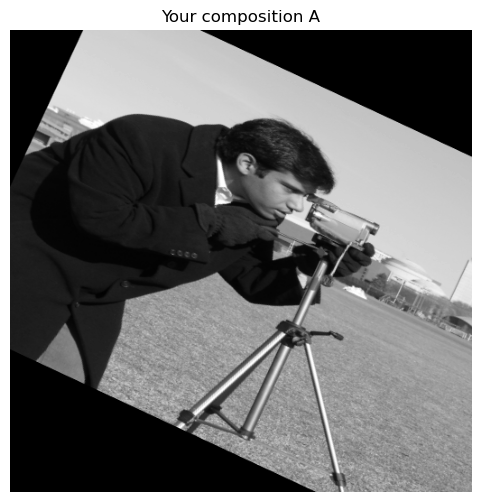

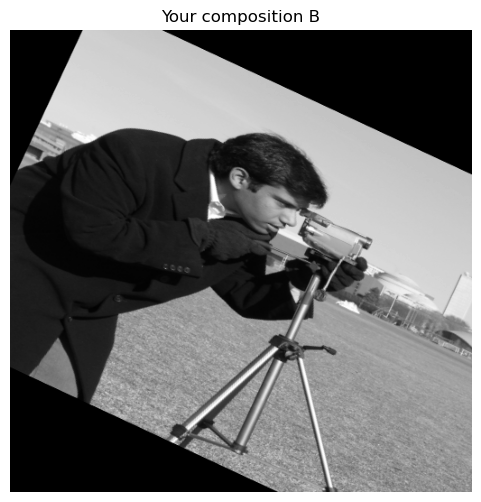

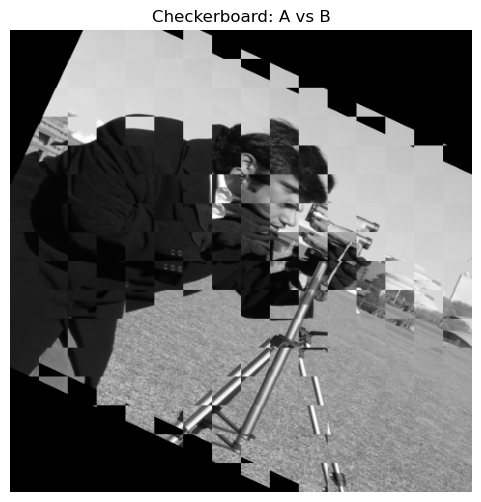

In [11]:
angle = 25
tx, ty = 40, 10
sx, sy = 1.2, 0.8

A = C_back @ translation_matrix(tx, ty) @ rotation_matrix(angle) @ scaling_matrix(sx, sy) @ C_to_origin
B = C_back @ rotation_matrix(angle) @ translation_matrix(tx, ty) @ scaling_matrix(sx, sy) @ C_to_origin

img_A = cv2.warpAffine(reference, A[:2, :], (w, h))
img_B = cv2.warpAffine(reference, B[:2, :], (w, h))

show_gray(img_A, "Your composition A")
show_gray(img_B, "Your composition B")
show_gray(checker_overlay(img_A, img_B), "Checkerboard: A vs B")
